In [5]:
#counting images
import os

empty_path = "parking-data/empty"
filled_path = "parking-data/not_empty"

empty_images = os.listdir(empty_path)
filled_images = os.listdir(filled_path)

total_empty = len(empty_images)
total_filled = len(filled_images)
total_images = total_empty + total_filled

print("Total images:", total_images)
print("Empty:", total_empty)
print("Filled:", total_filled)

Total images: 6090
Empty: 3045
Filled: 3045


In [6]:
#train/val/test split
from sklearn.model_selection import train_test_split

all_images = empty_images + filled_images
labels = [0]*total_empty + [1]*total_filled

X_train, X_temp, y_train, y_temp = train_test_split(all_images, labels, test_size=0.3, random_state=42) #70%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) #15%, 15%

print(len(X_train), len(X_val), len(X_test))

4263 913 914


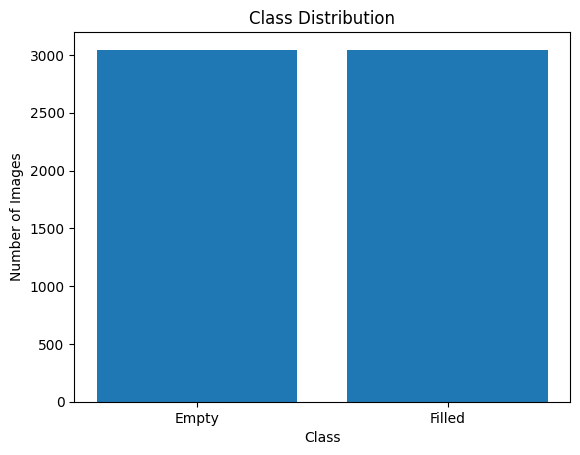

In [7]:
#class distribution
import matplotlib.pyplot as plt

classes = ['Empty', 'Filled']
counts = [total_empty, total_filled]

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [8]:
#image statistics
import cv2
import numpy as np

heights, widths = [], []
pixel_values = []

for folder in [empty_path, filled_path]:
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue
        
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)
        
        pixel_values.extend(img.flatten())

print("Min pixel:", np.min(pixel_values))
print("Max pixel:", np.max(pixel_values))
print("Mean pixel:", np.mean(pixel_values))
print("Median pixel:", np.median(pixel_values))

Min pixel: 0
Max pixel: 255
Mean pixel: 99.07381534039988
Median pixel: 91.0


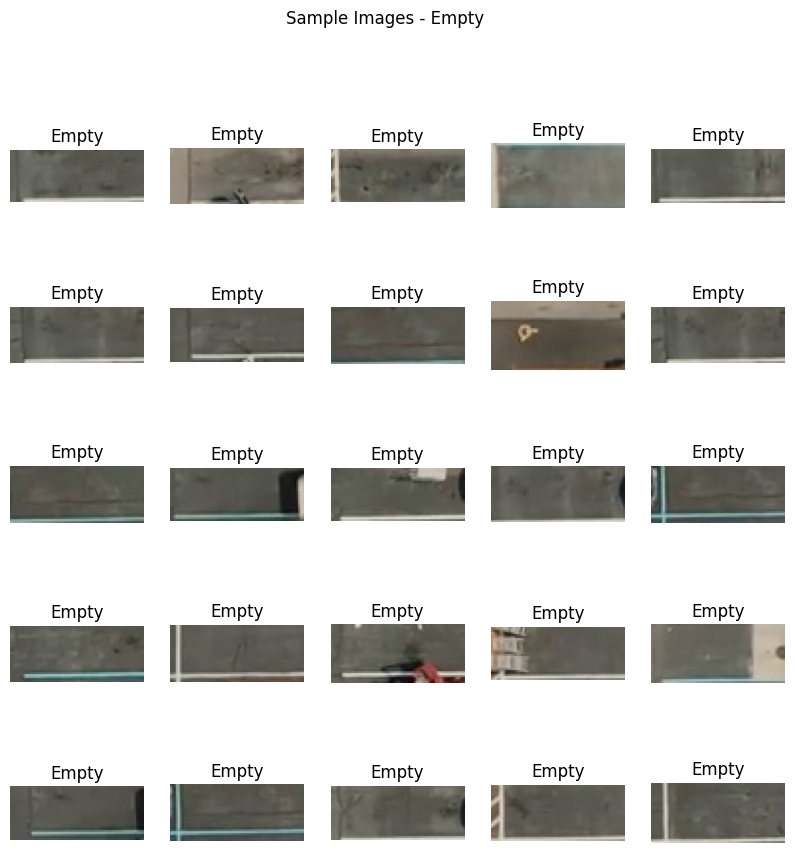

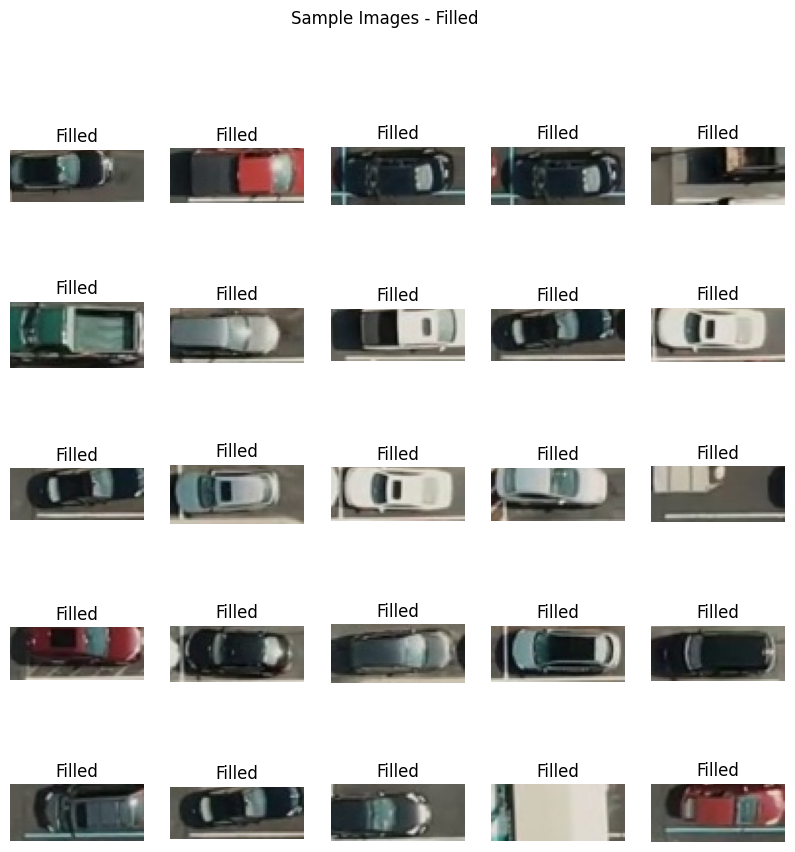

In [9]:
#sample visualisation
import random

def show_samples(folder, label):
    plt.figure(figsize=(10,10))
    
    images = random.sample(os.listdir(folder), 25)
    
    for i, img_name in enumerate(images):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(5,5,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    
    plt.suptitle(f"Sample Images - {label}")
    plt.show()

show_samples(empty_path, "Empty")
show_samples(filled_path, "Filled")

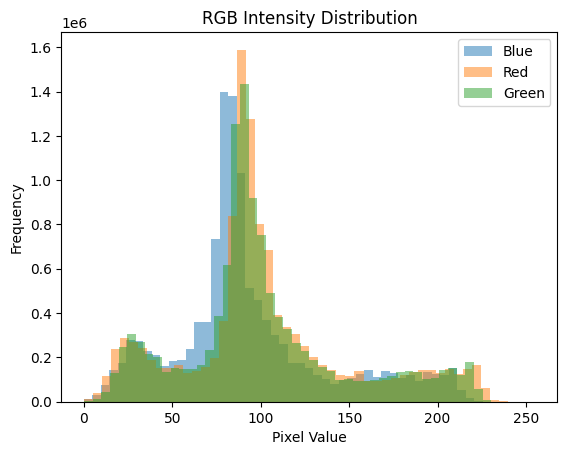

In [11]:
#colour and texture analysis
r, g, b = [], [], []

for folder in [empty_path, filled_path]:
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue
        
        r.extend(img[:,:,2].flatten())
        g.extend(img[:,:,1].flatten())
        b.extend(img[:,:,0].flatten())

plt.hist(b, bins=50, alpha=0.5, label='Blue')
plt.hist(r, bins=50, alpha=0.5, label='Red')
plt.hist(g, bins=50, alpha=0.5, label='Green')

plt.legend()
plt.title("RGB Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#correlation/heatmaps
# import seaborn as sns
# import pandas as pd

# df = pd.DataFrame({
#     'width': widths,
#     'height': heights
# })

# sns.heatmap(df.corr(), annot=True)
# plt.title("Correlation Heatmap")
# plt.show()

#Dataset does not include structured metadata such as bounding boxes or object dimensions.

In [13]:
#corrupt images
corrupt = []

for folder in [empty_path, filled_path]:
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            corrupt.append(img_name)

print("Corrupt images:", len(corrupt))

Corrupt images: 0


In [14]:
#duplicate images
import hashlib

hashes = set()
duplicates = 0

for folder in [empty_path, filled_path]:
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        with open(path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            
            if file_hash in hashes:
                duplicates += 1
            else:
                hashes.add(file_hash)

print("Duplicates:", duplicates)

Duplicates: 0
